In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import plotly.graph_objects as go

In [2]:
f = "../data/001_raw/ERA5_Oaxaca_2023.nc"
oax = xr.open_dataset(f)

f = "../data/001_raw/ERA5_Morelos_2023.nc"
mor = xr.open_dataset(f)


In [3]:
def temperatura_celsius(estado, variable = "t2m"):
    """Función que convierte la temperatura de Kelvin a grados Celsius.

    Args:
        estado (xarray.Dataset): Dataset que contien las variables climáticas del estado.
        variable (str, optional): Nombre de la variable en el dataset. Defaults to "t2m".

    Returns:
        xarray.DataArray: Variable seleccionada expresada en grados Celsius.
    """
    if variable == "t2m":
        return estado[variable] - 273.15
    return estado[variable]

oax["t2m_celsius"] = temperatura_celsius(oax, "t2m")
mor["t2m_celsius"] = temperatura_celsius(mor, "t2m")


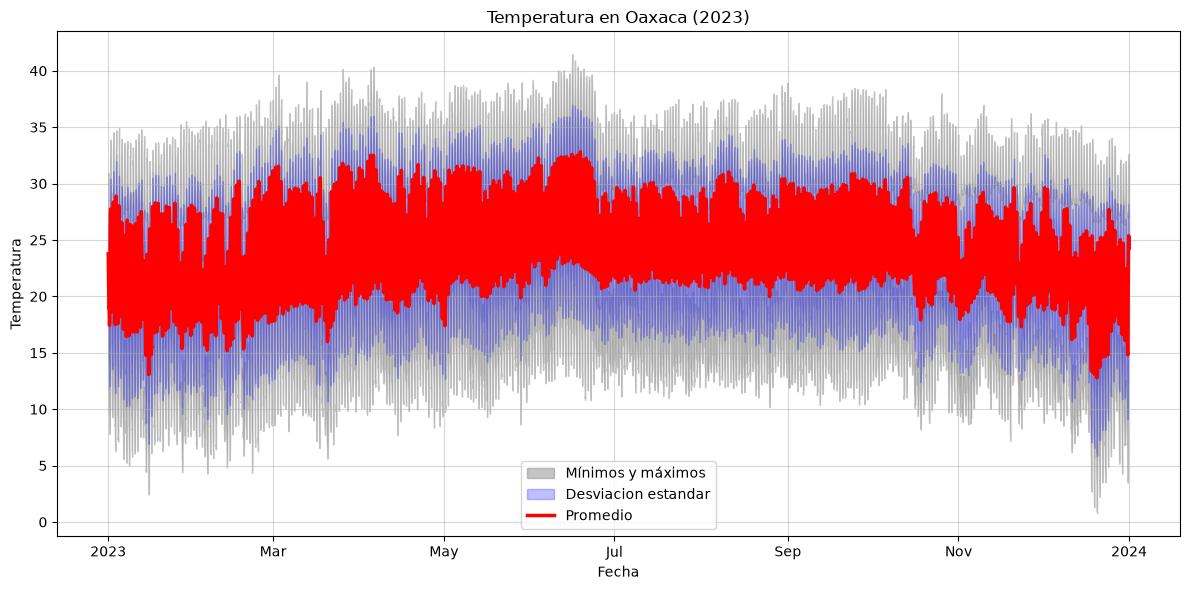

In [4]:
import matplotlib.pyplot as plt

def graficar_temperatura_desviacion(estado, nombre_estado, variable="t2m_celsius"):
    """Función para graficar una serie temporal con el promedio espacial, desviación estándar y mínimos-máximos.

        Args:
            estado (xarray.Dataset): Conjunto de datos climatológicos con dimensiones de tiempo, latitud y longitud.
            nombre_estado (str): Nombre de la entidad federativa para personalizar el título del gráfico.
            variable (str, optional): Nombre de la variable a procesar. Defaults to "t2m_celsius".
        """

   
    promedio = estado[variable].mean(dim=["latitude", "longitude"])
    std = estado[variable].std(dim=["latitude", "longitude"])
    max = estado[variable].max(dim=["latitude", "longitude"])
    min = estado[variable].min(dim=["latitude", "longitude"])
    
    _, ax = plt.subplots(figsize=(12, 6))

    ax.fill_between(promedio.time, 
                     min, 
                     max, 
                     color="gray", alpha = 0.45,label="Mínimos y máximos"
                     )
    
    ax.fill_between(promedio.time, 
                     promedio - std, 
                     promedio + std, 
                     color="blue", alpha=0.25, label="Desviacion estandar"
                     )
    
    promedio.plot(color="red", linewidth=2.5, label="Promedio")
    
    ax.set_title(f"Temperatura en {nombre_estado} (2023)")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Temperatura")
    ax.grid(True, alpha =0.5)
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
graficar_temperatura_desviacion(oax, "Oaxaca")
#graficar_temperatura_estado(mor, "Morelos")

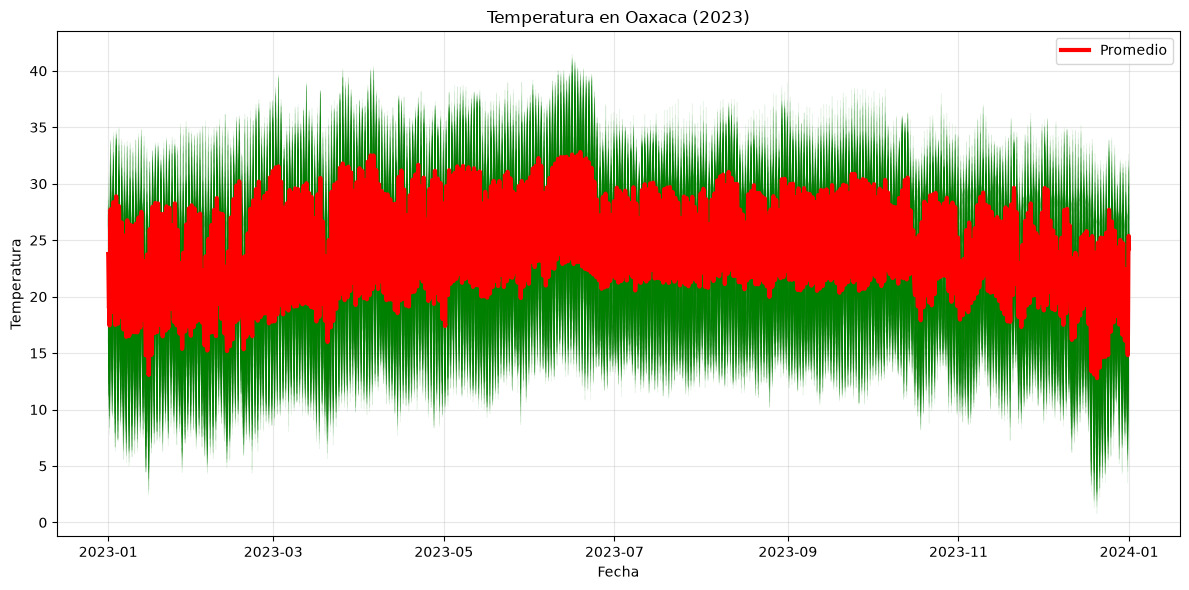

In [5]:
import matplotlib.pyplot as plt

def graficar_temperatura_lineas(estado, nombre_estado, variable="t2m_celsius"):
    """Crea un gráfico de espagueti con líneas semitransparentes para cada punto del mapa junto con el promedio regional.

    Args:
        estado (xarray_Dataset): Dataset con los datos climáticos organizados por tiempo y espacio.
        nombre_estado (str): Nombre de la entidad federativa para personalizar el título del gráfico.
        variable (str, optional): Nombre de la variable que se desea graficar. Defaults to "t2m_celsius".
    """

   
    promedio = estado[variable].mean(dim=["latitude", "longitude"])
    
    _, ax = plt.subplots(figsize=(12, 6))
    
    temperaturas = estado[variable].stack(punto=["latitude", "longitude"])
    
    ax.plot(temperaturas.time, temperaturas.values, color="green", alpha=0.08, linewidth=0.5)
    
    ax.plot(promedio.time, promedio.values, color="red", linewidth=3, label="Promedio")
    
    
    ax.set_title(f"Temperatura en {nombre_estado} (2023)")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Temperatura")
    ax.grid(True, alpha =0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
graficar_temperatura_lineas(oax, "Oaxaca")
#graficar_temperatura_estado(mor, "Morelos")

In [6]:
def filtrar_zona(estado, lat_norte, lat_sur, long_oeste, long_este):
    """Aplica un recorte por coordenadas para aislar un municipio o región en el mapa, mediante una caja de delimitación geográfica.

    Args:
        estado (xarray.Dataset): Dataset con la información meteorológica completa de la entidad.
        lat_norte (float): Punto decimal que define la frontera norte del área.
        lat_sur (float): Punto decimal que define la frontera sur del área.
        long_oeste (float): Límite oeste de la caja de selección (negativo).
        long_este (float): Límite este de la caja de selección (negativo).

    Returns:
        xarray.Dataset: Fragmento de datos correspondiente únicamente al cuadro delimitador.
    """

    area = estado.sel(
        latitude = slice (lat_norte,lat_sur),
        longitude = slice(long_oeste, long_este)
    )
    return area
    
huajuapan = filtrar_zona(oax,18.05,17.71,-97.92,-97.70)
huajuapan

<xarray.Dataset> Size: 1MB
Dimensions:      (time: 8760, latitude: 2, longitude: 1)
Coordinates:
  * time         (time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23:00:00
  * latitude     (latitude) float32 8B 18.0 17.75
  * longitude    (longitude) float32 4B -97.75
Data variables:
    u100         (time, latitude, longitude) float64 140kB ...
    v100         (time, latitude, longitude) float64 140kB ...
    u10          (time, latitude, longitude) float64 140kB ...
    v10          (time, latitude, longitude) float64 140kB ...
    t2m          (time, latitude, longitude) float64 140kB 292.8 291.3 ... 295.2
    ssrd         (time, latitude, longitude) float64 140kB ...
    t2m_celsius  (time, latitude, longitude) float64 140kB 19.63 18.11 ... 22.02
Attributes:
    Conventions:  CF-1.6
    history:      2024-03-28 09:15:45 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

In [7]:
def grafica_mapa_calor(estado, nombre_estado, mes, variable = "t2m_celsius"):
    """Visualiza la temperatura promedio por hora a lo largo de los días de un mes específico en un mapa de calor.

    Args:
        estado (xarray.Dataset): Conjunto de datos climáticos con dimensiones de tiempo y espacio.
        nombre_estado (str): Nombre del estado para etiquetar la gráfica.
        mes (int): Número del mes (1-12) seleccionado para el desglose diario.
        variable (str, optional): Variable meteorológica a graficar. Defaults to "t2m_celsius".
    """

    promedio = estado[variable].mean(dim=["latitude", "longitude"])
    estado = promedio.to_dataframe(name = "temperatura").reset_index()
    
    estado["Mes"] = estado["time"].dt.month
    estado["Dia"] = estado["time"].dt.day
    estado["Hora"] = estado["time"].dt.hour
    
    estado_mes = estado[estado['Mes'] == mes].copy()
    
    columna_hora = estado_mes.pivot_table(
        index='Hora', 
        columns='Dia', 
        values='temperatura', 
        aggfunc='mean'
    )
    
   
    meses_nombres = {
        1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril",5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto",9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"
    }
    nombre_mes = meses_nombres.get(mes)
    
    escala_calificacion = [
        [0.0, "rgb(69, 117, 180)"],  
        [0.5, "rgb(254, 224, 144)"],  
        [1.0, "rgb(215, 48, 39)"],  
    ]
    
    fig = go.Figure(
        go.Heatmap(
            x=columna_hora.columns,   # dias
            y=columna_hora.index,     # horas del día 
            z=columna_hora.values,    # temperaturas
            colorscale=escala_calificacion,
            xgap=2,
            ygap=2,   
            colorbar=dict(title="Temp °C"),
            hovertemplate="<b>Día: %{x}</b><br>Hora: %{y}:00<br>Temperatura: %{z:.1f}°C<extra></extra>",
        )
    )
    
    fig.update_layout(
        title=f"Mapa de calor de {nombre_estado} — {nombre_mes} (2023)",
        xaxis_title="Día del Mes",
        yaxis_title="Hora del Día",
        xaxis=dict(
            tickmode='linear',
            tick0=1,
            dtick=1 
        ),
        yaxis=dict(
            tickmode='linear',
            tick0=0,
            dtick=2 
        ),
        height=500, 
        template="plotly_white"
    )

    fig.show()
    return fig

fig_mes = grafica_mapa_calor(huajuapan, "Oaxaca", 2)
